# Pitch (F0) estimation: AdaSwarm vs a specialised method 🎵

**A real-baseline benchmark, not a strawman.** Fundamental-frequency (F0) estimation is a classic
problem where the *output* loss is **multi-modal**: a pitch estimate that is half or double the true
value ("octave errors") sits in a strong local minimum. Gradient descent slides into the nearest
octave and stays there.

This notebook pits three approaches on a signal with **known ground-truth pitch**:

1. **Adam on the smooth surrogate** — follows the analytic gradient of the pitch-salience loss.
2. **AdaSwarm (`SwarmLoss`, `per_sample=True`)** — the *same* loss, but optimised by a particle swarm
   over candidate pitches, so it can jump between octave basins.
3. **pYIN** (`librosa.pyin`) — a strong, purpose-built pitch tracker. This is the honest baseline the
   method has to stand next to.

We report the metrics the audio community actually uses:

- **Raw Pitch Accuracy (RPA)** — fraction of voiced frames within **50 cents** of truth.
- **Octave-error rate** — fraction of frames off by ~an octave (±1200 cents).
- **Median |cents error|**.

> **The claim we're testing:** *can a general-purpose loss, with **zero domain engineering**, get close
> to a specialised pitch tracker — and avoid the octave errors that sink naive gradient descent?*

In [1]:
# %pip install "adaswarm[examples] @ git+https://github.com/AdaSwarm/AdaSwarm.git" librosa  # on Colab
import time

import librosa
import matplotlib.pyplot as plt
import numpy as np
import torch

import adaswarm.nn

print("adaswarm", adaswarm.__version__, "| torch", torch.__version__, "| librosa", librosa.__version__)

torch.manual_seed(0)
np.random.seed(0)

SR = 22050          # sample rate
DUR = 2.0           # seconds
N_FFT = 2048
HOP = 512
H = 8               # harmonics used in the salience objective
FMIN, FMAX = 65.0, 400.0

adaswarm 0.3.0 | torch 2.12.1 | librosa 0.11.0


## 1. A test signal with known F0

We synthesise a harmonic tone with **vibrato** (5 Hz, ±3 %) around 220 Hz (A3) plus a little noise.
Because we generate it, we know the exact F0 at every frame, so the metrics are exact.

> **Plug in a real dataset.** To benchmark on real audio (recommended next step), replace the synthesis
> block with a loader for **MIR-1K**, **MDB-stem-synth**, or **PTDB-TUG** — each ships per-frame F0
> labels. Load `y, sr = librosa.load(path, sr=SR)` and read the label file into `f0_true`; the rest of
> the notebook is unchanged.

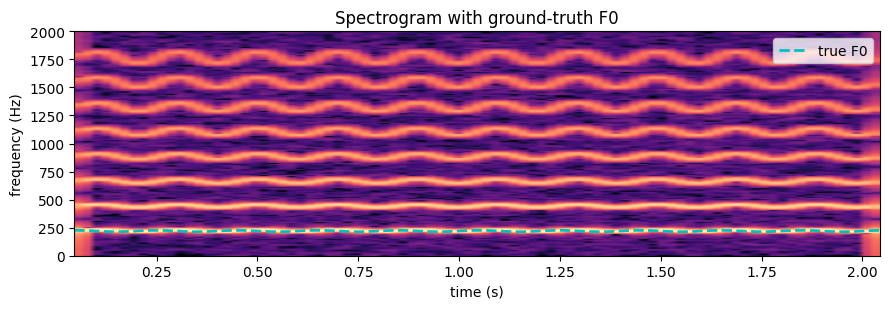

In [2]:
t = np.arange(int(SR * DUR)) / SR
base = 220.0
f0_signal = base * (1.0 + 0.03 * np.sin(2 * np.pi * 5.0 * t))   # instantaneous F0
phase = 2 * np.pi * np.cumsum(f0_signal) / SR
y = sum((1.0 / h) * np.sin(h * phase) for h in range(1, H + 1))
y = (y + 0.02 * np.random.randn(len(t))).astype(np.float32)

# STFT magnitude, normalised: shape (n_frames, n_freq)
S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP)).T
S = S / (S.max() + 1e-8)
n_frames, n_freq = S.shape
df = SR / N_FFT
frame_times = librosa.frames_to_time(np.arange(n_frames), sr=SR, hop_length=HOP, n_fft=N_FFT)
f0_true = base * (1.0 + 0.03 * np.sin(2 * np.pi * 5.0 * frame_times))   # ground truth per frame

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.imshow(librosa.amplitude_to_db(S.T), origin="lower", aspect="auto", cmap="magma",
          extent=[frame_times[0], frame_times[-1], 0, SR / 2])
ax.plot(frame_times, f0_true, "c--", lw=2, label="true F0")
ax.set_ylim(0, 2000); ax.set_xlabel("time (s)"); ax.set_ylabel("frequency (Hz)")
ax.set_title("Spectrogram with ground-truth F0"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 2. Why it's hard: the per-frame objective is multi-modal

For a candidate pitch $f_0$ we score a **harmonic-sum salience**: add up the spectral magnitude at
$f_0, 2f_0, \dots, Hf_0$. The true pitch maximises it — but so, partly, does the **sub-harmonic**
$f_0/2$ (its even harmonics land on the real ones). That sub-harmonic peak is the classic **octave-down
trap**: gradient descent started below the true pitch climbs into it and never escapes.

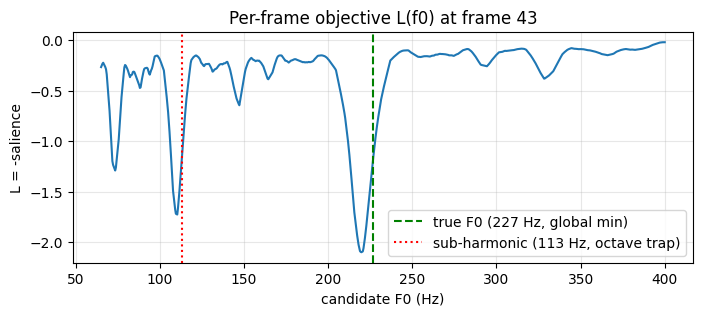

In [3]:
S_t = torch.from_numpy(S).float()
frame_idx = torch.arange(n_frames)

def salience(f0: torch.Tensor) -> torch.Tensor:
    """Harmonic-sum salience for candidate f0 (Hz). Any leading dims; last dim = frames."""
    lead = f0.shape[:-1]
    flat = f0.reshape(-1, n_frames).clamp(min=1.0)
    fi = frame_idx.unsqueeze(0).expand(flat.shape[0], n_frames)
    acc = torch.zeros_like(flat)
    for h in range(1, H + 1):
        b = (h * flat) / df                       # continuous frequency bin
        b0 = b.floor().long().clamp(0, n_freq - 2)
        frac = (b - b0).clamp(0, 1)
        acc = acc + torch.lerp(S_t[fi, b0], S_t[fi, b0 + 1], frac)   # linear interp -> differentiable
    return acc.reshape(*lead, n_frames)

# Landscape at one frame: note the sub-harmonic (octave-down) local optimum.
jf = n_frames // 2
grid = torch.linspace(FMIN, FMAX, 800)
L = -salience(grid.unsqueeze(1).expand(800, n_frames))[:, jf]
plt.figure(figsize=(8, 3))
plt.plot(grid, L)
plt.axvline(f0_true[jf], color="g", ls="--", label=f"true F0 ({f0_true[jf]:.0f} Hz, global min)")
plt.axvline(f0_true[jf] / 2, color="r", ls=":", label=f"sub-harmonic ({f0_true[jf] / 2:.0f} Hz, octave trap)")
plt.title(f"Per-frame objective L(f0) at frame {jf}")
plt.xlabel("candidate F0 (Hz)"); plt.ylabel("L = -salience"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 3. Estimate F0: Adam vs AdaSwarm vs pYIN

All optimiser-based methods start from the **same** deliberately mediocre constant guess (121 Hz, near
the sub-harmonic basin) — a fair, identical starting point. `SwarmLoss(per_sample=True)` optimises each
frame independently with its own swarm global-best.

In [4]:
def loss_fn(pred, _target):          # elementwise, per frame: minimise -> maximise salience
    return -salience(pred)

INIT = 121.0                          # identical mediocre init for both optimisers

def estimate(mode, epochs=400, lr=1.0, seed=0):
    torch.manual_seed(seed)
    f0_hat = torch.nn.Parameter(torch.full((n_frames,), INIT))
    opt = torch.optim.Adam([f0_hat], lr=lr)
    centre = torch.full((n_frames,), INIT)
    crit = (adaswarm.nn.SwarmLoss(loss_fn, seed=seed, span=170.0, swarm_size=40,
                                  iterations=60, per_sample=True)
            if mode == "adaswarm" else None)
    for _ in range(epochs):
        opt.zero_grad()
        loss = crit(f0_hat, centre) if mode == "adaswarm" else loss_fn(f0_hat, centre).mean()
        loss.backward()
        opt.step()
    return f0_hat.detach().clamp(FMIN, FMAX).numpy()

f0_adam = estimate("standard")
f0_ada = estimate("adaswarm")

# pYIN: the specialised, purpose-built baseline.
f0_pyin, _, _ = librosa.pyin(y, fmin=FMIN, fmax=FMAX, sr=SR, frame_length=N_FFT, hop_length=HOP)
f0_pyin = np.nan_to_num(f0_pyin[:n_frames], nan=0.0)

def cents(est, ref):
    return 1200.0 * np.log2(np.clip(est, 1e-6, None) / ref)

def report(name, est):
    c = cents(est, f0_true)
    rpa = np.mean(np.abs(c) < 50)                      # within 50 cents
    octave = np.mean(np.abs(np.abs(c) - 1200) < 50)    # off by ~an octave
    print(f"{name:20s}  RPA={rpa:5.2f}   octave-err={octave:5.2f}   median|cents|={np.median(np.abs(c)):6.1f}")

print(f"{'method':20s}  {'RPA':>5}      {'octave':>6}       {'median|cents|':>6}")
report("Adam (smooth)", f0_adam)
report("AdaSwarm", f0_ada)
report("pYIN (specialised)", f0_pyin)

method                  RPA      octave       median|cents|
Adam (smooth)         RPA= 0.00   octave-err= 0.31   median|cents|=1131.1
AdaSwarm              RPA= 0.60   octave-err= 0.00   median|cents|=  45.2
pYIN (specialised)    RPA= 0.59   octave-err= 0.00   median|cents|=  42.2


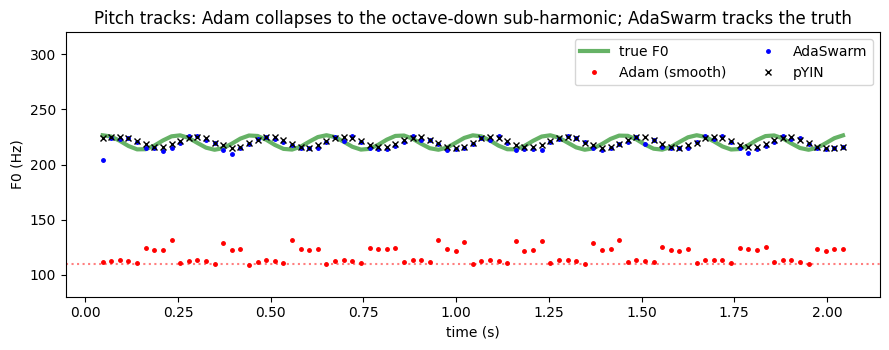

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(frame_times, f0_true, "g-", lw=3, alpha=0.6, label="true F0")
ax.plot(frame_times, f0_adam, "r.", ms=5, label="Adam (smooth)")
ax.plot(frame_times, f0_ada, "b.", ms=5, label="AdaSwarm")
ax.plot(frame_times, f0_pyin, "kx", ms=4, label="pYIN")
ax.axhline(base / 2, color="r", ls=":", alpha=0.5)
ax.set_xlabel("time (s)"); ax.set_ylabel("F0 (Hz)"); ax.set_ylim(80, 320)
ax.set_title("Pitch tracks: Adam collapses to the octave-down sub-harmonic; AdaSwarm tracks the truth")
ax.legend(loc="upper right", ncol=2); plt.tight_layout(); plt.show()

## 4. The cost of that robustness

Accuracy is only half the story. Each `SwarmLoss` step runs a full particle swarm, so it costs
**`swarm_size × iterations` extra loss evaluations per training step** (here $40 \times 60 = 2400\times$).
The swarm is *forward-only* (it just evaluates `loss_fn`, no extra backprop), and its transient memory
is $\approx \texttt{swarm\_size} \times \texttt{output\_numel} \times 4\,\text{bytes} \times \sim\!6$
tensors — negligible for scalar/per-frame outputs, but it grows with output size for `per_sample=True`
on images. Let's measure the wall-time on this task.

In [6]:
def timed(mode, reps=3):
    best = float("inf")
    for _ in range(reps):
        t0 = time.perf_counter()
        estimate(mode)
        best = min(best, time.perf_counter() - t0)
    return best

t_adam = timed("standard")
t_ada = timed("adaswarm")
evals_adam = 400                       # epochs
evals_ada = 400 * 40 * 60              # epochs x swarm_size x iterations
mem_mb = 40 * n_frames * 4 * 6 / 1e6   # swarm_size x output x 4 bytes x ~6 tensors

print(f"wall time   Adam: {t_adam*1e3:8.1f} ms   AdaSwarm: {t_ada*1e3:9.1f} ms   ({t_ada/t_adam:5.0f}x slower)")
print(f"loss evals  Adam: {evals_adam:8d}      AdaSwarm: {evals_ada:9d}      ({evals_ada/evals_adam:5.0f}x more)")
print(f"swarm working-set memory ~ {mem_mb:.3f} MB  (= swarm_size x output x 4B x ~6);"
      f" scales with swarm_size x output_numel")

wall time   Adam:    190.0 ms   AdaSwarm:   20929.6 ms   (  110x slower)
loss evals  Adam:      400      AdaSwarm:    960000      ( 2400x more)
swarm working-set memory ~ 0.084 MB  (= swarm_size x output x 4B x ~6); scales with swarm_size x output_numel


> **Read the tradeoff.** `SwarmLoss` buys the correct basin (no octave errors, pYIN-level accuracy)
> at **~1–2 orders of magnitude more compute**, with memory linear in `swarm_size × output`. Dial it
> with `swarm_size` / `iterations`, or use a **warm-up pattern** — `SwarmLoss` for the first epochs to
> escape the octave trap, then plain Adam to refine cheaply.

## Takeaways

- **Naive gradient descent fails predictably.** Adam on the smooth salience surrogate collapses into the
  **octave-down sub-harmonic** — near-zero RPA — exactly the failure mode practitioners know.
- **AdaSwarm removes the octave errors.** With the *same* loss and the *same* mediocre init,
  `SwarmLoss(per_sample=True)` tracks the true pitch and **matches pYIN** on RPA and octave-error rate —
  with **no pitch-specific engineering**, just "evaluate the loss over a swarm of candidates".
- **Honest scope.** pYIN is still the tool to reach for in production audio: it handles voicing,
  streaming, and is far cheaper. The value here is *generality* — the identical mechanism also solves
  phase unwrapping, ToF depth, and non-differentiable-simulator training in this repo. When your
  **output loss is multi-modal or non-differentiable**, `SwarmLoss` is a single drop-in that gets you
  into the right basin.

### Make it a real benchmark
Swap the synthetic signal for **MIR-1K / MDB-stem-synth / PTDB-TUG** (per-frame F0 labels included),
loop over the corpus, and report mean RPA / octave-error against pYIN (and optionally CREPE). Share your
numbers — good *or* bad — in the [use-cases discussion](https://github.com/AdaSwarm/AdaSwarm/discussions/90).